In [101]:
#definições
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
DATABASE_PATH = Path("../data/outputs/result_test_500_ficticias.csv")

In [102]:
#visualização
df = pd.read_csv(DATABASE_PATH)
df.head()

,date,description_raw,description_normalized,amount_cents,signed_amount_cents,direction,transaction_type,balance_after_cents,doc_number,transaction_code,source_page,source_text,extraction_method,warnings,review_required,category
0,2025-01-01,"1.548,85 (+) 64207 700000000000163 Dep dinheir...",Dep dinheiro ATM 01/01 12:50 CENTRO,154885,154885,credit,deposito,404885,700000000000163,64207,1,"1.548,85 (+) 64207 700000000000163 Dep dinheir...",synthetic,NaN,False,deposito
1,2025-01-02,"94,23 (-) 13015 700000000001154 Pix - Enviado ...",Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,-9423,debit,pix,395462,700000000001154,13015,1,"94,23 (-) 13015 700000000001154 Pix - Enviado ...",synthetic,NaN,False,manutenção
2,2025-01-03,"373,74 (-) 53369 700000000002066 Pix - Enviado...",Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,-37374,debit,pix,358088,700000000002066,53369,1,"373,74 (-) 53369 700000000002066 Pix - Enviado...",synthetic,NaN,False,financeamento
3,2025-01-05,"558,20 (-) 69535 700000000003755 Pix - Enviado...",Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,-55820,debit,pix,302268,700000000003755,69535,1,"558,20 (-) 69535 700000000003755 Pix - Enviado...",synthetic,NaN,False,multas
4,2025-01-06,"708,13 (-) 22742 700000000004844 Pix - Enviado...",Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,-70813,debit,pix,231455,700000000004844,22742,1,"708,13 (-) 22742 700000000004844 Pix - Enviado...",synthetic,NaN,False,manutenção


In [103]:
#descartar colunas inuteis

df = df.drop(columns=[
    "date",
    "description_raw", 
    "amount_cents",
    "doc_number", 
    "transaction_code", 
    "source_text", 
    "source_page",
    "extraction_method",
    "balance_after_cents", 
    "warnings"])

df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [104]:
#remover duplicatas
df = df.drop_duplicates()
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [105]:
#remover nulos
df = df.dropna(axis=0, inplace=False)
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


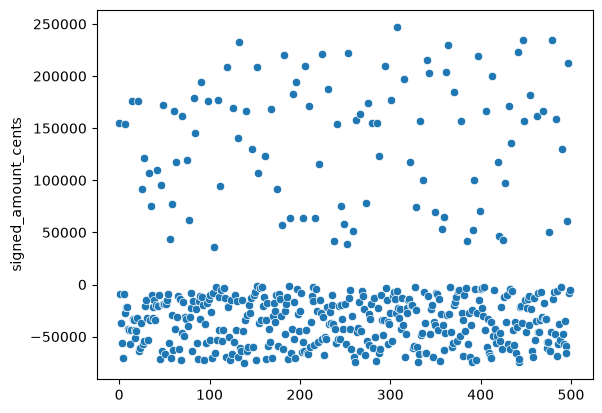

In [106]:
#identificação de outliers da variavel numerica

sns.scatterplot(x=range(len(df['signed_amount_cents'])), y=df['signed_amount_cents'])
plt.show()


In [107]:
from scipy import stats

df['z_score'] = stats.zscore(df['signed_amount_cents'])

outliers = df[abs(df['z_score']) > 3]

outliers.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category,z_score
308,Transferência recebida 23/03 09:52 PAGAMENTO D...,247486,credit,transferencia,False,pagamento,3.162045
447,Dep dinheiro ATM 11/10 11:34 CENTRO,234921,credit,deposito,False,deposito,3.001445
479,Pix - Recebido 26/11 21:00 PLATAFORMA DE CORRIDAS,234931,credit,pix,False,ganho de corrida,3.001573


In [108]:
#dataframe sem outliers
df = df[abs(df['z_score']) < 3]

df = df.drop(columns='z_score')
df.head()

,description_normalized,signed_amount_cents,direction,transaction_type,review_required,category
0,Dep dinheiro ATM 01/01 12:50 CENTRO,154885,credit,deposito,False,deposito
1,Pix - Enviado 02/01 16:58 MANUTENÇÃO E OFICINA,-9423,debit,pix,False,manutenção
2,Pix - Enviado 03/01 11:27 PARCELA DE FINANCIAM...,-37374,debit,pix,False,financeamento
3,Pix - Enviado 05/01 07:27 PAGAMENTO DE MULTA,-55820,debit,pix,False,multas
4,Pix - Enviado 06/01 22:43 MANUTENÇÃO E OFICINA,-70813,debit,pix,False,manutenção


In [109]:
#transformar dados qualitativos em valores numericos
df = pd.get_dummies(df, columns= [ 'direction', 'transaction_type', 'description_normalized'])

df.head()

,signed_amount_cents,review_required,category,direction_credit,direction_debit,transaction_type_deposito,transaction_type_pix,transaction_type_transferencia,description_normalized_Dep dinheiro ATM 01/01 12:50 CENTRO,description_normalized_Dep dinheiro ATM 01/01 21:10 CENTRO,...,description_normalized_Transferência recebida 21/12 18:31 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 22/10 12:39 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 22/11 07:40 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 22/12 11:40 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 23/04 10:45 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 23/05 13:03 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 23/07 16:42 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 26/03 17:01 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 31/01 14:20 PAGAMENTO DE SERVIÇO,description_normalized_Transferência recebida 31/08 07:40 PAGAMENTO DE SERVIÇO
0,154885,False,deposito,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1,-9423,False,manutenção,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-37374,False,financeamento,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-55820,False,multas,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-70813,False,manutenção,False,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [110]:
#verificar desbalanceamento de classes

df_categorias = (df.groupby('category').size().reset_index(name="quantidade"))
df_categorias.head(20)

,category,quantidade
0,acessórios,26
1,alimentação,33
2,celular/chip,38
3,cnh,20
4,combustivel,41
5,deposito,39
6,financeamento,29
7,ganho de corrida,26
8,ipva,31
9,lavagem,35


In [ ]:
#separação dos dados para o treinamento da arvore de decisão e treinamento do modelo

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

target = "category"
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
)

modelo.fit(X_train, y_train)

TypeError: DecisionTreeClassifier.__init__() got an unexpected keyword argument 'class_weigth'. Did you mean 'class_weight'?